In [1]:
import time
from pprint import pprint

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets
import torchvision.transforms as transforms

import helper_utils
import model_architectures

helper_utils.set_seed(42)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
model_CNN = model_architectures.OptimizedCNN()
model_resnet = model_architectures.ResNet34()

In [10]:
def get_data_loaders_with_validation(batch_size, val_fraction=0.1) :
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    full_trainset = datasets.CIFAR10(root='./cifar10', train=True, download=True, transform=transform_train)
    full_valset = datasets.CIFAR10(root='./cifar10', train=True, download=True, transform=transform_test)

    total_train = len(full_trainset)
    val_size = int(val_fraction * total_train)
    train_size = total_train - val_size

    train_subset_temp, val_subset_temp = random_split(full_trainset, [train_size, val_size])

    train_set = Subset(full_trainset, train_subset_temp.indices)
    val_set = Subset(full_valset, val_subset_temp.indices)

    test_set = datasets.CIFAR10(root='./cifar10', train=False, download=True, transform=transform_test)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)
    
    return train_loader, val_loader, test_loader

In [7]:
def train_and_evaluate(model, optimizer, scheduler, device, n_epochs, train_loader, val_loader) :
    model = model.to(device)
    loss_fcn = nn.CrossEntropyLoss()
    pbar = helper_utils.NestedProgressBar(total_epochs=n_epochs, total_batches=len(train_loader), epoch_message_freq=1)
    for epoch in range(n_epochs) :
        pbar.update_epoch(epoch + 1)
        train_loss, _ = helper_utils.train_epoch(model, train_loader, optimizer, loss_fcn, device, pbar)
        val_acc = helper_utils.evaluate_accuracy(model, val_loader, device)
        pbar.maybe_log_epoch(epoch+1, message=f"Epoch {epoch+1} - Train Loss: {train_loss:.4f}, Val Acc: {val_acc:.4f}")
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_acc)
            else:
                scheduler.step()

    pbar.close("Training complete!")

In [8]:
n_epochs = 10
batch_size = 128

In [11]:
train_loader, val_loader, test_loader = get_data_loaders_with_validation(batch_size=batch_size, val_fraction=0.2)

In [12]:
optimizer_CNN = optim.Adam(model_CNN.parameters(), lr=0.001, weight_decay=1e-5)
scheduler_CNN = optim.lr_scheduler.ReduceLROnPlateau(optimizer_CNN, 'max', patience=3, factor=0.5)

train_and_evaluate(model_CNN, optimizer_CNN, scheduler_CNN, device, n_epochs, train_loader, val_loader)

Current Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Current Batch:   0%|          | 0/313 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1 - Train Loss: 1.7375, Val Acc: 0.4941


Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 8 - Train Loss: 0.9596, Val Acc: 0.7116


Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 9 - Train Loss: 0.9258, Val Acc: 0.7177


Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 10 - Train Loss: 0.9012, Val Acc: 0.7350
Training complete!


In [13]:
optimizer_resnet = optim.SGD(model_resnet.parameters(), lr=0.1, momentum=0.8, weight_decay=5e-4)
scheduler_resnet = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_resnet, T_max=200)

train_and_evaluate(model_CNN, optimizer_CNN, scheduler_CNN, device, n_epochs, train_loader, val_loader)

Current Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Current Batch:   0%|          | 0/313 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1 - Train Loss: 0.8830, Val Acc: 0.7450


Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 8 - Train Loss: 0.7677, Val Acc: 0.7612


Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 9 - Train Loss: 0.7496, Val Acc: 0.7781


Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 10 - Train Loss: 0.7429, Val Acc: 0.7745
Training complete!


In [14]:
def get_model_size(model) :
    param_size = 0
    for param in model.parameters() :
        param_size += param.nelement() * param.element_size()

    buffer_size = 0
    for buffer in model.buffers() :
        buffer_size += buffer.nelement() * buffer.element_size()

    size_in_mb = (param_size + buffer_size) / 1024 ** 2
    return size_in_mb

In [18]:
def measure_inference_time(model, input_data, num_iterations=100) :
    model.eval()
    device = next(model.parameters()).device
    input_data = input_data.to(device)
    with torch.no_grad() :
        for _ in range(10) :
            _ = model(input_data)

    start_time = time.time()
    with torch.no_grad() :
        for _ in range(num_iterations) :
            _ = model(input_data)
    end_time = time.time()

    avg_time = (end_time - start_time) / num_iterations
    return avg_time * 1000
        

In [19]:
def evaluate_efficiency(model, test_loader, device) :
    model_size = get_model_size(model)
    data_iter = iter(test_loader)
    batch = next(data_iter)
    inputs = batch[0]
    sample_input = inputs[:1].to(device)
    inf_time = measure_inference_time(model, sample_input)
    test_accuracy = helper_utils.evaluate_accuracy(model, test_loader, device)

    return {
        "accuracy": test_accuracy,
        "model_size_mb": model_size,
        "inference_time_ms": inf_time,
    }

In [24]:
models = {
    "Optimized CNN": model_CNN,
    "ResNet 34": model_resnet
}

results = {}

for name, model in models.items():
    model = model.to(device)   # Move model to GPU/CPU
    model.eval()               # Evaluation mode

    results[name] = evaluate_efficiency(model, test_loader, device)

results_df = pd.DataFrame(results).T
print(results_df)

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

               accuracy  model_size_mb  inference_time_ms
Optimized CNN    0.7719       9.196831           0.600953
ResNet 34        0.1046      81.250069           6.601577


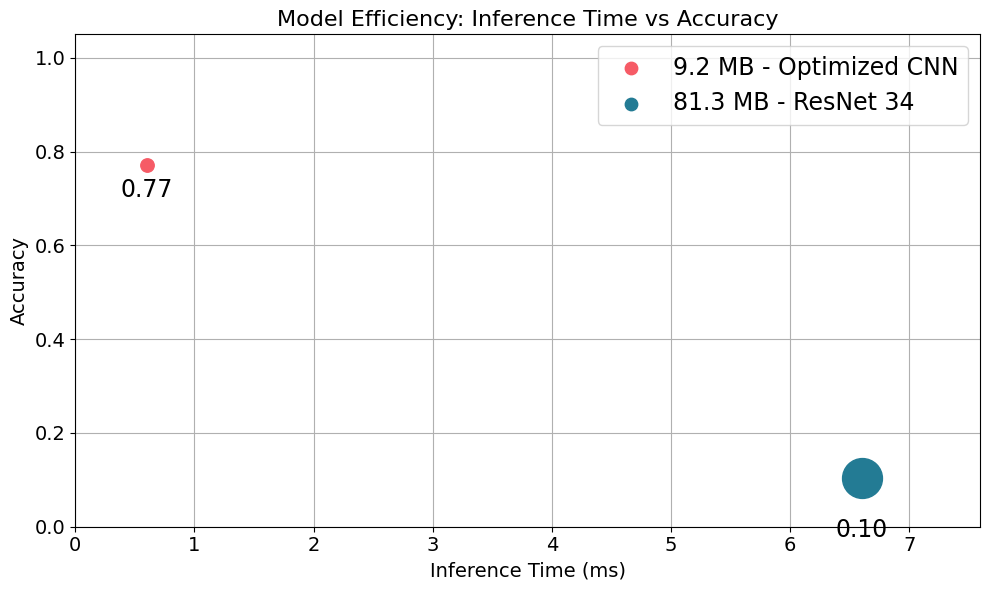

In [25]:
helper_utils.plot_efficiency_analysis(results_df)

In [26]:
def select_best_model_weighted(results, weights=None):
    results = results.to_dict(orient="index")
    
    if weights is None:
        weights = {"accuracy": 0.5, "model_size_mb": 0.2, "inference_time_ms": 0.3}

    metrics = list(weights.keys())
    normalized = {name: {} for name in results}

    for metric in metrics:
        values = [res[metric] for res in results.values()]
        min_val, max_val = min(values), max(values)
        range_val = max_val - min_val if max_val != min_val else 1.0
        for name, res in results.items():
            value = res[metric]
            if metric == "accuracy":
                norm_value = (value - min_val) / range_val
            else:
                norm_value = 1 - (value - min_val) / range_val
            normalized[name][metric] = norm_value

    scores = {
        name: sum(weights[metric] * normalized[name][metric] for metric in metrics)
        for name in results
    }

    best_model = max(scores.items(), key=lambda x: x[1])
    return best_model[0], scores

In [28]:
def select_best_model_constraint_based(results, max_size_mb, max_inference_ms):
    results = results.to_dict(orient="index")
    viable_models = {
        name: metrics for name, metrics in results.items()
        if metrics["model_size_mb"] <= max_size_mb and
           metrics["inference_time_ms"] <= max_inference_ms
    }

    if not viable_models:
        print("No models meet all constraints. Consider relaxing constraints.")
        return None

    best_model = max(viable_models.items(), key=lambda x: x[1]["accuracy"])
    return best_model[0], viable_models

In [29]:
resnet_results = helper_utils.load_resnet_table()
resnet_results

,depth,accuracy,model_size_mb,inference_time_ms
model,,,,
ResNet18,18,0.92,42,2.0
ResNet34,34,0.93,81,3.8
ResNet50,50,0.94,98,5.0
ResNet101,101,0.95,168,8.0
ResNet152,152,0.96,230,12.0


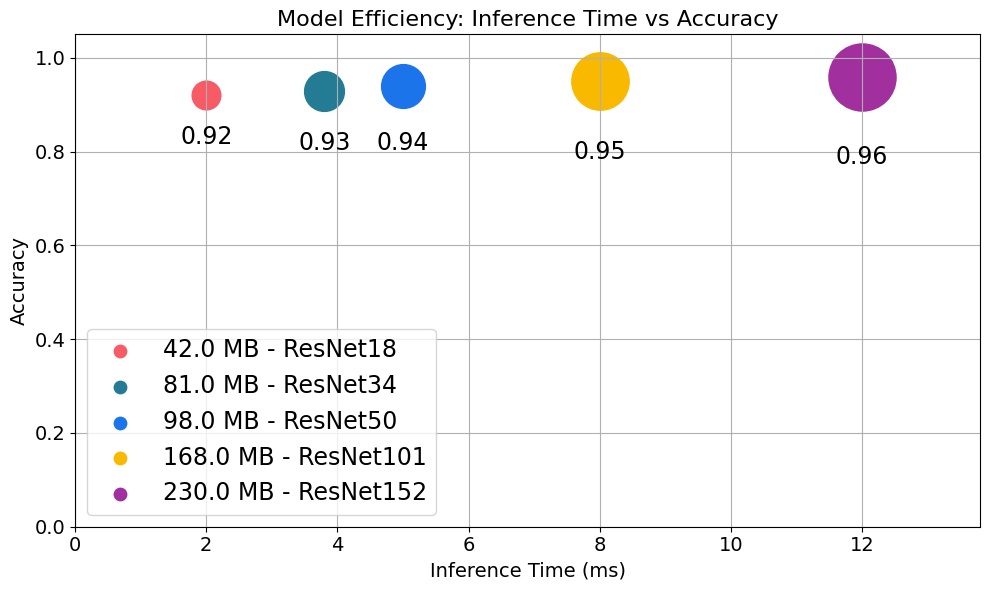

In [31]:
helper_utils.plot_efficiency_analysis(resnet_results)

In [32]:
best_model_weighted, weighted_scores = select_best_model_weighted(resnet_results)

print(f"Best model by weighted criteria: {best_model_weighted}")
print("Weighted scores:")
pprint(weighted_scores)

Best model by weighted criteria: ResNet50
Weighted scores:
{'ResNet101': 0.5609574468085103,
 'ResNet152': 0.5,
 'ResNet18': 0.5,
 'ResNet34': 0.5295106382978727,
 'ResNet50': 0.6004255319148929}


In [33]:
best_model_constrains, viable_models = select_best_model_constraint_based(resnet_results, max_size_mb=100, max_inference_ms=4)

print(f"Best model by constraints: {best_model_constrains}")
print("Viable models:")
pprint(viable_models)

Best model by constraints: ResNet34
Viable models:
{'ResNet18': {'accuracy': 0.92,
              'depth': 18,
              'inference_time_ms': 2.0,
              'model_size_mb': 42},
 'ResNet34': {'accuracy': 0.93,
              'depth': 34,
              'inference_time_ms': 3.8,
              'model_size_mb': 81}}
